# Animation solver traces

Plots the per-frame CSVs exported by `MTile.Tests/Animation/TraceExportTests.cs` —
phase, limb angles, root offsets, and solved angle corrections over time, for
scenarios like *hold right on flat ground*.

**Regenerate the data** (writes `.probe/traces/*.csv` at the repo root):
```
dotnet test MTile.Tests/MTile.Tests.csproj --filter "FullyQualifiedName~TraceExport"
```
Scenarios: `holdright_flat` (real sim: idle → spin-up → steady run),
`constant_run_90` / `constant_walk_25` (solver isolated, constant velocity).

Columns: `phase`, `clip`, `grounded`, `vx/vy`, `vert_offset` (δ), `horiz_offset` (d.x),
`rot_<bone>` (final local rotation, rad), `corr_<bone>` (solved Δθ, rad).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRACES = Path('..') / '.probe' / 'traces'

# Categorical palette (validated, fixed order — color follows the bone, never its rank).
PAL = ['#2a78d6', '#008300', '#e87ba4', '#eda100', '#1baf7a', '#eb6834', '#4a3aa7', '#e34948']
BONE_COLOR = {
    'leg_l_upper': PAL[0], 'leg_r_upper': PAL[1],
    'leg_l_lower': PAL[2], 'leg_r_lower': PAL[3],
    'foot_l':      PAL[4], 'foot_r':      PAL[5],
    'arm_l_upper': PAL[6], 'arm_r_upper': PAL[7],
    'arm_l_lower': PAL[6], 'arm_r_lower': PAL[7],
    'hip': '#52514e', 'chest': '#52514e', 'head': '#52514e',
}

plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e6e5e1', 'grid.linewidth': 0.6,
    'axes.titlesize': 11, 'axes.labelsize': 9, 'legend.fontsize': 8,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'lines.linewidth': 2.0,
})

def load(name):
    df = pd.read_csv(TRACES / f'{name}.csv')
    # Per-frame phase step, loop wrap folded out (a 1->0 wrap is not a jump).
    d = df['phase'].diff()
    df['dphase'] = np.where(d < -0.5, d + 1.0, d)
    return df

def mark_context(ax, df):
    """Shade airborne frames; draw a vertical line at each clip switch."""
    air = df['grounded'] == 0
    if air.any():
        ax.fill_between(df['frame'], 0, 1, where=air, transform=ax.get_xaxis_transform(),
                        color='#e6e5e1', alpha=0.5, linewidth=0, zorder=0)
    switches = df.index[df['clip'] != df['clip'].shift()][1:]
    for i in switches:
        ax.axvline(df.loc[i, 'frame'], color='#9b9a93', linewidth=0.8, linestyle=':')

sorted(p.stem for p in TRACES.glob('*.csv'))

['constant_run_90', 'constant_walk_25', 'holdright_flat']

In [2]:
SCENARIO = 'holdright_flat'   # <- pick from the list above
BONES = ['leg_l_upper', 'leg_r_upper', 'leg_l_lower', 'leg_r_lower']

df = load(SCENARIO)
df[['frame', 'phase', 'clip', 'grounded', 'vx', 'vert_offset']].describe()

,frame,phase,grounded,vx,vert_offset
count,360.000000,360.000000,360.000000,360.000000,360.000000
mean,179.500000,0.422054,0.988889,199.232222,0.372408
std,104.067286,0.284377,0.104968,7.424720,1.017665
min,0.000000,0.000000,0.000000,100.000000,-0.637900
25%,89.750000,0.197167,1.000000,200.000000,0.000000
50%,179.500000,0.397280,1.000000,200.067000,0.000000
75%,269.250000,0.631363,1.000000,200.133000,0.019800
max,359.000000,0.987790,1.000000,200.133000,3.795700


## Phase & phase rate
A healthy locomotion trace: `phase` is a clean sawtooth; `dphase` hovers near one
value. Seesawing `dphase` (crawl in stance, sprint in swing) or spikes are the
cadence pathologies. Dotted verticals = clip switches; gray bands = airborne.

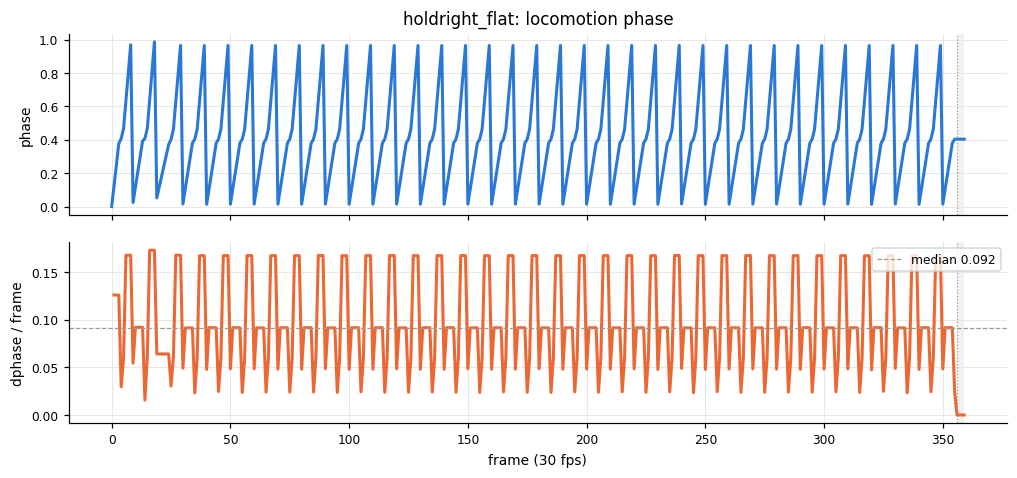

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 4.6), sharex=True,
                               gridspec_kw={'hspace': 0.15})
ax1.plot(df['frame'], df['phase'], color=PAL[0])
ax1.set_ylabel('phase')
ax1.set_title(f'{SCENARIO}: locomotion phase')
mark_context(ax1, df)

ax2.plot(df['frame'], df['dphase'], color=PAL[5])
ax2.axhline(df['dphase'].iloc[20:].median(), color='#9b9a93', linewidth=0.8,
            linestyle='--', label=f"median {df['dphase'].iloc[20:].median():.3f}")
ax2.set_ylabel('dphase / frame')
ax2.set_xlabel('frame (30 fps)')
ax2.legend(loc='upper right')
mark_context(ax2, df)
plt.show()

## Limb angles (final pose)
`rot_<bone>` is the FINAL local rotation the player sees (clip @ solved φ + Δθ +
in-solve ease). Vertical near-jumps here are exactly the visible snaps.

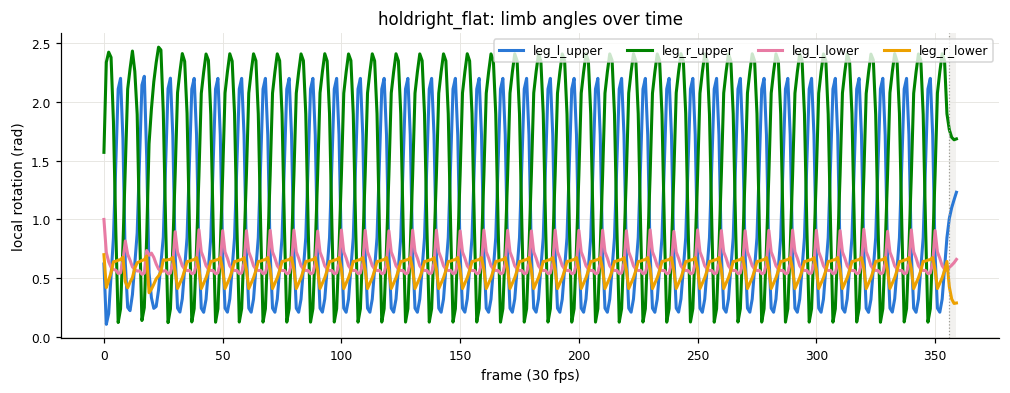

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.6))
for b in BONES:
    ax.plot(df['frame'], df[f'rot_{b}'], color=BONE_COLOR[b], label=b)
ax.set_ylabel('local rotation (rad)')
ax.set_xlabel('frame (30 fps)')
ax.set_title(f'{SCENARIO}: limb angles over time')
ax.legend(ncols=len(BONES), loc='upper right')
mark_context(ax, df)
plt.show()

## Per-frame angle deltas (the jerk view)
`|Δrot|` per frame, wrapped. Spikes ≥ ~0.4 rad read as single-frame limb snaps
on screen; a smooth fast swing stays below ~0.3 at run cadence.

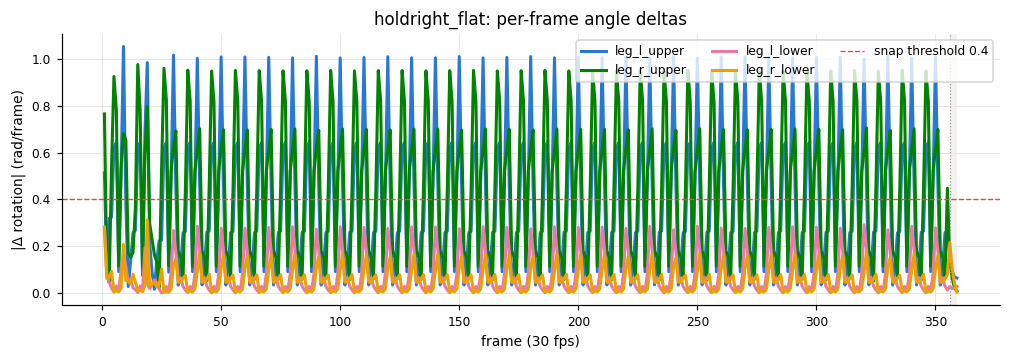

In [5]:
def wrapped_delta(s):
    d = s.diff()
    return (d + np.pi) % (2 * np.pi) - np.pi

fig, ax = plt.subplots(figsize=(11, 3.2))
for b in BONES:
    ax.plot(df['frame'], wrapped_delta(df[f'rot_{b}']).abs(), color=BONE_COLOR[b], label=b)
ax.axhline(0.4, color='#e34948', linewidth=0.9, linestyle='--', label='snap threshold 0.4')
ax.set_ylabel('|Δ rotation| (rad/frame)')
ax.set_xlabel('frame (30 fps)')
ax.set_title(f'{SCENARIO}: per-frame angle deltas')
ax.legend(ncols=3, loc='upper right')
mark_context(ax, df)
plt.show()

## Solved root offsets
`vert_offset` (δ) is the stance bob that keeps the planted foot grounded — should
oscillate gently and settle to 0 in flight. `horiz_offset` (d.x) is the small
fore-aft sway that absorbs the no-slip singularity at the foot's turning point —
should stay within ±1px-ish; sustained drift means it's absorbing cadence.

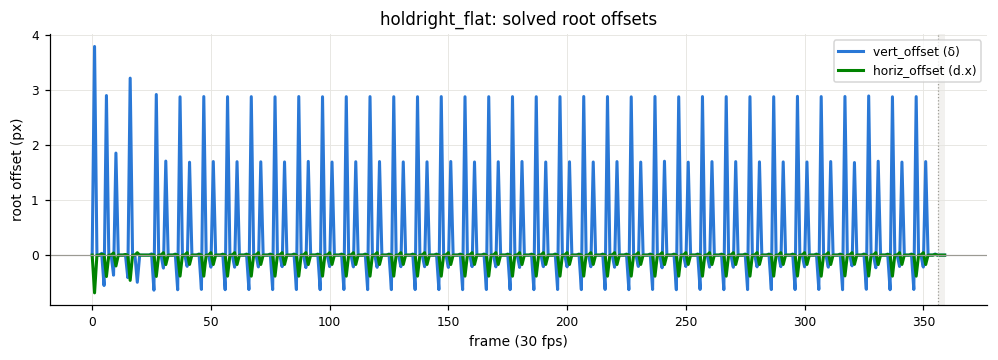

In [6]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(df['frame'], df['vert_offset'], color=PAL[0], label='vert_offset (δ)')
ax.plot(df['frame'], df['horiz_offset'], color=PAL[1], label='horiz_offset (d.x)')
ax.axhline(0, color='#9b9a93', linewidth=0.8)
ax.set_ylabel('root offset (px)')
ax.set_xlabel('frame (30 fps)')
ax.set_title(f'{SCENARIO}: solved root offsets')
ax.legend(loc='upper right')
mark_context(ax, df)
plt.show()

## Angle corrections (Δθ)
The solver's per-bone IK trim on top of the authored clip. Legs carry small
bounded corrections in stance; a per-stride bump is the Δθ bridge over the
contact-handoff Δφ hop (expected). Sustained large values = a constraint
fighting the clip; values at the ±3.2 box = saturation.

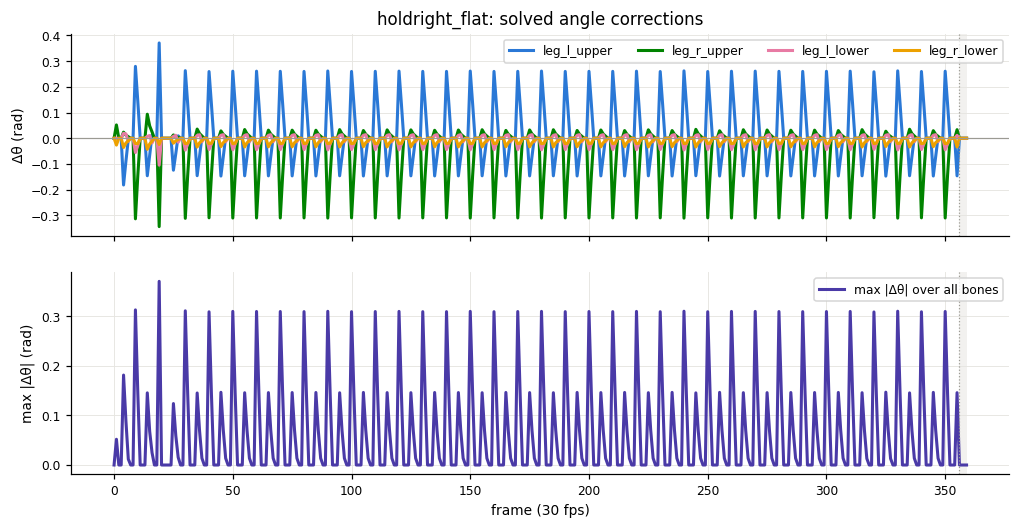

In [7]:
corr_cols = [c for c in df.columns if c.startswith('corr_')]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.2), sharex=True,
                               gridspec_kw={'hspace': 0.18})
for b in BONES:
    ax1.plot(df['frame'], df[f'corr_{b}'], color=BONE_COLOR[b], label=b)
ax1.axhline(0, color='#9b9a93', linewidth=0.8)
ax1.set_ylabel('Δθ (rad)')
ax1.set_title(f'{SCENARIO}: solved angle corrections')
ax1.legend(ncols=len(BONES), loc='upper right')
mark_context(ax1, df)

ax2.plot(df['frame'], df[corr_cols].abs().max(axis=1), color=PAL[6],
         label='max |Δθ| over all bones')
ax2.set_ylabel('max |Δθ| (rad)')
ax2.set_xlabel('frame (30 fps)')
ax2.legend(loc='upper right')
mark_context(ax2, df)
plt.show()

## Compare scenarios
Same metric across traces — e.g. is the sim-driven run jerkier than the
constant-velocity control? (Extra sim noise ⇒ the gap is solver-vs-sim coupling.)

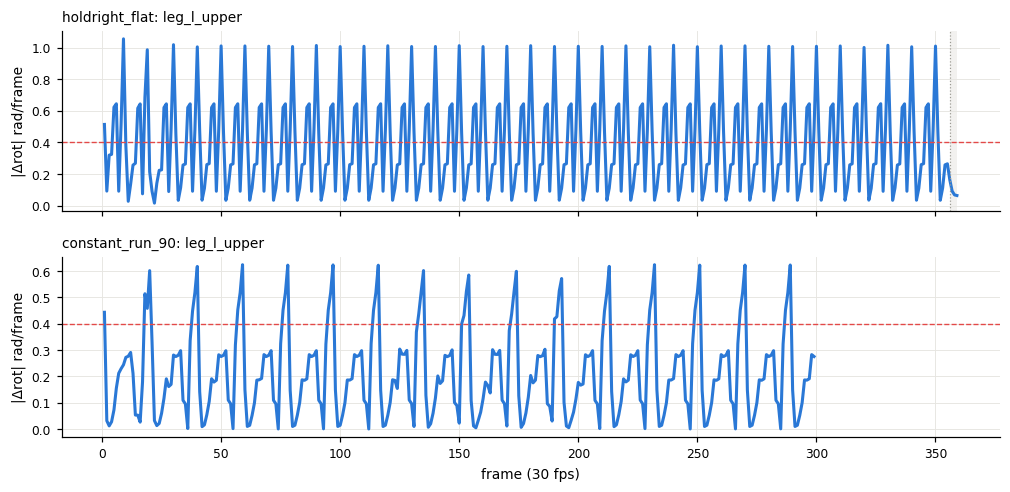

In [8]:
COMPARE = ['holdright_flat', 'constant_run_90']
BONE = 'leg_l_upper'

fig, axes = plt.subplots(len(COMPARE), 1, figsize=(11, 2.4 * len(COMPARE)),
                         sharex=True, gridspec_kw={'hspace': 0.25})
for ax, name in zip(np.atleast_1d(axes), COMPARE):
    d = load(name)
    ax.plot(d['frame'], wrapped_delta(d[f'rot_{BONE}']).abs(), color=BONE_COLOR[BONE])
    ax.axhline(0.4, color='#e34948', linewidth=0.9, linestyle='--')
    ax.set_ylabel('|Δrot| rad/frame')
    ax.set_title(f'{name}: {BONE}', loc='left', fontsize=9)
    mark_context(ax, d)
np.atleast_1d(axes)[-1].set_xlabel('frame (30 fps)')
plt.show()